# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [ ]:
from pathlib import Path

import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

Loaded: pngtree-pink-rose-flower-isolated-on-transparent-background-png-image_15600350.png
Size: (360, 360), mode: RGB


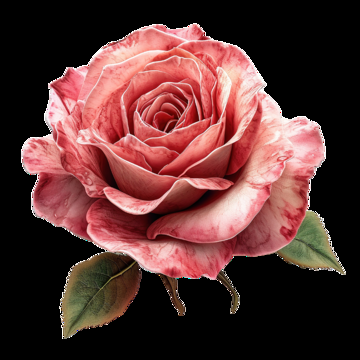

In [ ]:
image_path = Path("pngtree-pink-rose-flower-isolated-on-transparent-background-png-image_15600350.png")
image = Image.open(image_path).convert("RGB")

print(f"Loaded: {image_path.name}")
print(f"Size: {image.size}, mode: {image.mode}")
display(image)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [ ]:
width, height = image.size

scale_x, scale_y = 2, 2
new_size = (width * scale_x, height * scale_y)

print(f"Original size: {image.size}")
print(f"Scaled size: {new_size}")

Original size: (360, 360)
Scaled size: (720, 720)


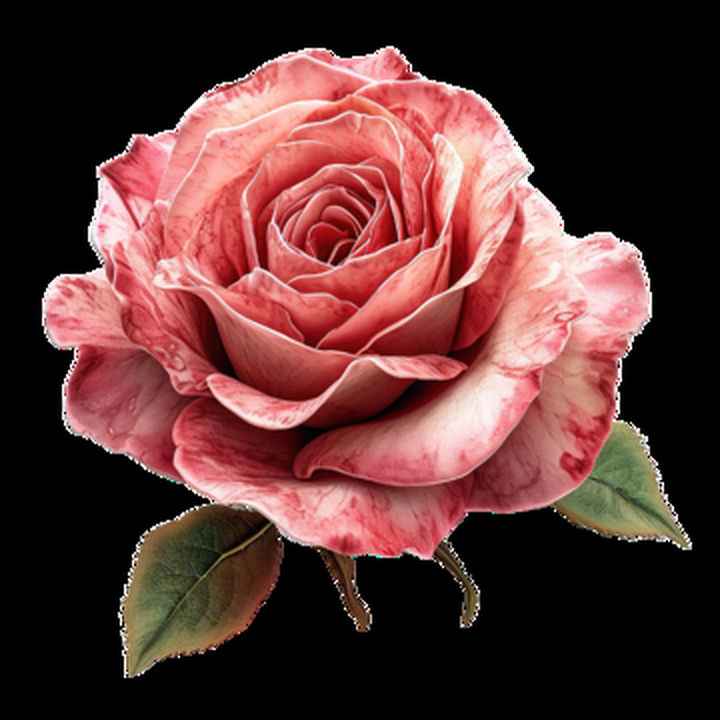

In [ ]:
scaled_image = image.resize(new_size, Image.Resampling.LANCZOS)

display(scaled_image)

In [ ]:
scaled_path = Path("task1_1_scaled.jpg")
scaled_image.save(scaled_path, quality=95)
print(f"Saved: {scaled_path} | size: {scaled_image.size}")

Saved: task1_1_scaled.jpg | size: (720, 720)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

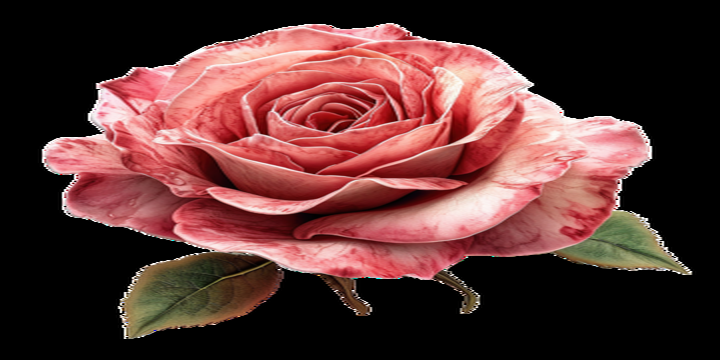

In [ ]:
horizontal_size = (width * 2, height)
horizontally_scaled = image.resize(horizontal_size, Image.Resampling.LANCZOS)
display(horizontally_scaled)

In [ ]:
horizontal_path = Path("task1_1_stretched_horizontal.jpg")
horizontally_scaled.save(horizontal_path, quality=95)
print(f"Saved: {horizontal_path} | size: {horizontally_scaled.size}")

Saved: task1_1_stretched_horizontal.jpg | size: (720, 360)


Original size: (360, 360)
Horizontal stretch size: (720, 360)


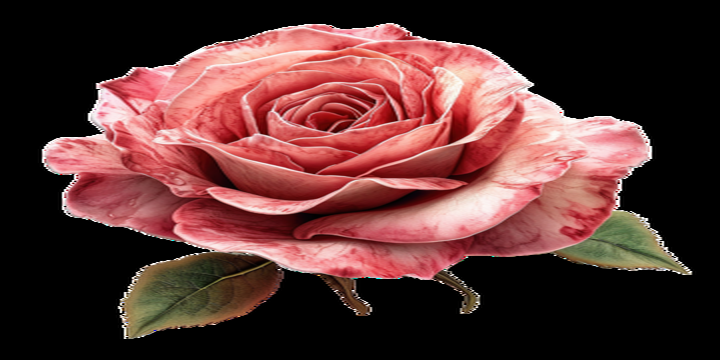

In [ ]:
print(f"Original size: {image.size}")
print(f"Horizontal stretch size: {horizontally_scaled.size}")
display(horizontally_scaled)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Saved: task1_2_rotated.jpg | size: (492, 492)


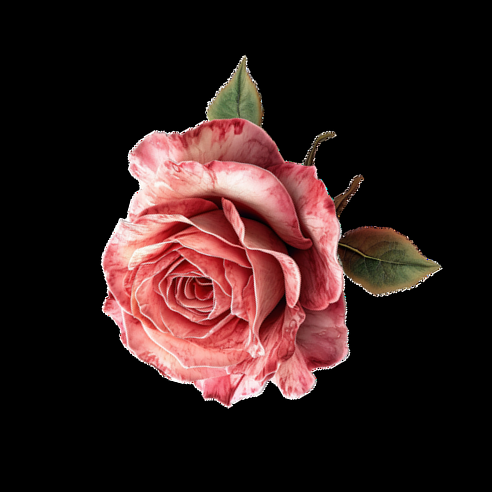

In [ ]:
rotated_image = image.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)
rotated_path = Path("task1_2_rotated.jpg")
rotated_image.save(rotated_path, quality=95)

print(f"Saved: {rotated_path} | size: {rotated_image.size}")
display(rotated_image)

### 3. Shear

In [ ]:
shear_width, shear_height = image.size
print(f"Image dimensions: {shear_width} x {shear_height}")

Image dimensions: 360 x 360


In [ ]:
shear_factor = 0.5
shear_matrix = (1, -shear_factor, 0, 0, 1, 0)
output_size = (int(shear_width + abs(shear_factor) * shear_height), shear_height)

print(f"Shear factor: {shear_factor}")
print(f"Output canvas: {output_size}")

Shear factor: 0.5
Output canvas: (540, 360)


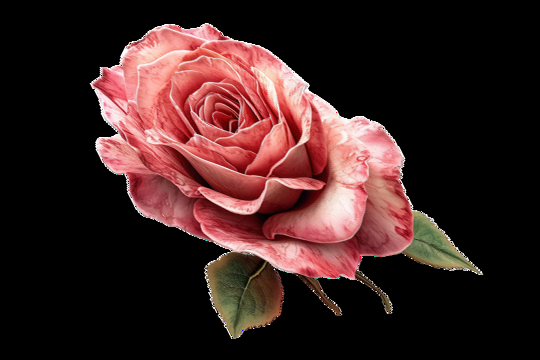

In [ ]:
sheared_image = image.transform(
    output_size,
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC,
)

display(sheared_image)

In [ ]:
sheared_path = Path("task1_3_sheared.jpg")
sheared_image.save(sheared_path, quality=95)
print(f"Saved: {sheared_path} | size: {sheared_image.size}")

Saved: task1_3_sheared.jpg | size: (540, 360)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

Saved: negative_numpy.jpg


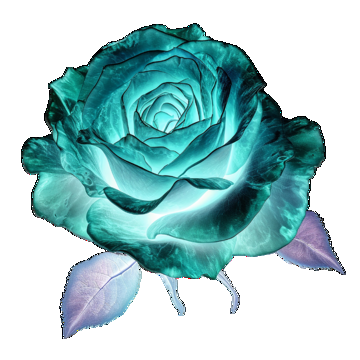

In [ ]:
image_array = np.array(image)
negative_array = 255 - image_array
negative_image = Image.fromarray(negative_array.astype(np.uint8))

negative_path = Path("negative_numpy.jpg")
negative_image.save(negative_path, quality=95)
print(f"Saved: {negative_path}")
display(negative_image)

Saved: negative_pil.jpg


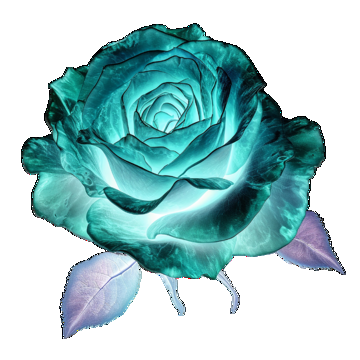

In [ ]:
negative_pil = ImageOps.invert(image)
negative_pil_path = Path("negative_pil.jpg")
negative_pil.save(negative_pil_path, quality=95)

print(f"Saved: {negative_pil_path}")
display(negative_pil)

Saved: log_transformed.jpg


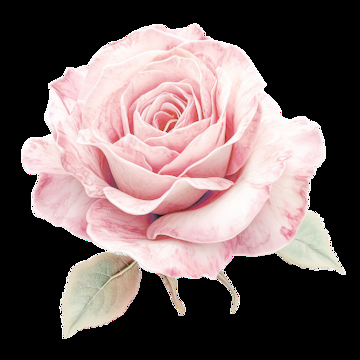

In [ ]:
image_array_float = image_array.astype(np.float32)
constant = 255 / np.log1p(255)
log_array = constant * np.log1p(image_array_float)
log_array = np.clip(log_array, 0, 255).astype(np.uint8)
log_image = Image.fromarray(log_array)

log_path = Path("log_transformed.jpg")
log_image.save(log_path, quality=95)
print(f"Saved: {log_path}")
display(log_image)

Saved: gamma_transformed.jpg | gamma=0.5


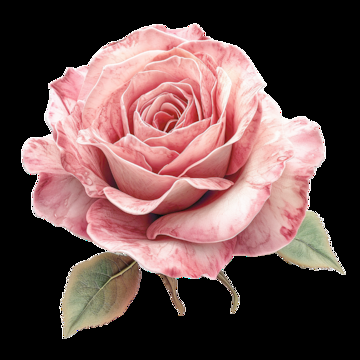

In [18]:
gamma = 0.5
gamma_array = 255 * ((image_array / 255) ** gamma)
gamma_image = Image.fromarray(np.clip(gamma_array, 0, 255).astype(np.uint8))

gamma_path = Path("gamma_transformed.jpg")
gamma_image.save(gamma_path, quality=95)
print(f"Saved: {gamma_path} | gamma={gamma}")
display(gamma_image)